In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from keras.preprocessing.image import load_img, img_to_array

base_dir = r"D:\archive\datasets\extracted_images"  # Folder containing subfolders for each class

# Parameters
image_size = (256, 256)  # Resize all images to this size for uniformity

# Initialize data and labels
data = []
labels = []
image_paths = []

# Loop through each class folder
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)

    if os.path.isdir(class_path):  # Ensure it's a directory
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                # Load and preprocess image
                image = load_img(image_path, target_size=image_size)
                image = img_to_array(image)
                image = image / 255.0  # Normalize pixel values

                # Append data, label, and path
                data.append(image.flatten())  # Flatten the image into a 1D array
                labels.append(class_name)
                image_paths.append(image_path)
            except Exception as e:
                print(f"Error loading image {image_path}: {e}")

# Convert data and labels to numpy arrays
data = np.array(data)
labels = np.array(labels)

# Encode labels to integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

In [16]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_dir = r'D:\archive\datasets\extracted_images'
IMG_SIZE = 224  
BATCH_SIZE = 16  

class_folders = [f for f in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, f))]
NUM_CLASSES = len(class_folders)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Class names: {class_folders}')

all_images = []
all_labels = []

for label, class_name in enumerate(class_folders):
    class_dir = os.path.join(dataset_dir, class_name)
    for image_name in os.listdir(class_dir):
        image_path = os.path.join(class_dir, image_name)
        if image_path.endswith(('jpg', 'jpeg', 'png')):
            image = tf.keras.preprocessing.image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
            image_array = tf.keras.preprocessing.image.img_to_array(image)
            all_images.append(image_array)
            all_labels.append(label)

all_images = np.array(all_images)
all_labels = np.array(all_labels)

Number of classes: 23
Class names: ['MEN-Denim', 'MEN-Jackets_Vests', 'MEN-Pants', 'MEN-Shirts_Polos', 'MEN-Shorts', 'MEN-Suiting', 'MEN-Sweaters', 'MEN-Sweatshirts_Hoodies', 'MEN-Tees_Tanks', 'WOMEN-Blouses_Shirts', 'WOMEN-Cardigans', 'WOMEN-Denim', 'WOMEN-Dresses', 'WOMEN-Graphic_Tees', 'WOMEN-Jackets_Coats', 'WOMEN-Leggings', 'WOMEN-Pants', 'WOMEN-Rompers_Jumpsuits', 'WOMEN-Shorts', 'WOMEN-Skirts', 'WOMEN-Sweaters', 'WOMEN-Sweatshirts_Hoodies', 'WOMEN-Tees_Tanks']


In [18]:
X_train, X_val, y_train, y_val = train_test_split(all_images, all_labels, test_size=0.3, random_state=33)

train_datagen = ImageDataGenerator(
    rescale=1./255,  
    rotation_range=30, 
    width_shift_range=0.2,  
    height_shift_range=0.2,  
    shear_range=0.2,  
    zoom_range=0.2,  
    horizontal_flip=True,  
    fill_mode='nearest'  
)

val_datagen = ImageDataGenerator(rescale=1./255) 

train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE)
vae_generator = train_datagen.flow(X_train, X_train, batch_size=BATCH_SIZE)
val_vae_generator = train_datagen.flow(X_val, X_val, batch_size=BATCH_SIZE)
val_generator = val_datagen.flow(X_val, y_val, batch_size=BATCH_SIZE)
generator = train_datagen.flow(all_images, all_labels, batch_size=BATCH_SIZE)

NUM_CLASSES = len(np.unique(y_train))
class_indices = {class_name: idx for idx, class_name in enumerate(class_folders)}
print(f'Class indices: {class_indices}')

Class indices: {'MEN-Denim': 0, 'MEN-Jackets_Vests': 1, 'MEN-Pants': 2, 'MEN-Shirts_Polos': 3, 'MEN-Shorts': 4, 'MEN-Suiting': 5, 'MEN-Sweaters': 6, 'MEN-Sweatshirts_Hoodies': 7, 'MEN-Tees_Tanks': 8, 'WOMEN-Blouses_Shirts': 9, 'WOMEN-Cardigans': 10, 'WOMEN-Denim': 11, 'WOMEN-Dresses': 12, 'WOMEN-Graphic_Tees': 13, 'WOMEN-Jackets_Coats': 14, 'WOMEN-Leggings': 15, 'WOMEN-Pants': 16, 'WOMEN-Rompers_Jumpsuits': 17, 'WOMEN-Shorts': 18, 'WOMEN-Skirts': 19, 'WOMEN-Sweaters': 20, 'WOMEN-Sweatshirts_Hoodies': 21, 'WOMEN-Tees_Tanks': 22}


In [19]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Conv2D, Conv2DTranspose, BatchNormalization, Dropout
from keras.models import Model
from tensorflow.keras.losses import mse
from tensorflow.keras import layers
from tensorflow.keras import backend as K

IMG_SIZE = 224
LATENT_DIM = 64
NUM_CLASSES = len(np.unique(y_train))
BATCH_SIZE = 16
EPOCHS = 50

In [79]:
print(f"Total images loaded: {total_images}")
print(f"X_train shape: {X_train_shape}")
print(f"X_test shape: {X_test_shape}")

Total images loaded: 10335
X_train shape: 7234
X_test shape: 3101


In [21]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        # Optionally clip for stability:
        z_log_var = K.clip(z_log_var, -10, 10)
        # Compute the KL divergence loss and add it
        kl_loss = -0.5 * K.mean(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var))
        self.add_loss(kl_loss)
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

latent_dim = 256 
input_shape = (224, 224, 3)  

inputs = Input(shape=input_shape)
x = Conv2D(64, (3, 3), activation='relu', padding='same', strides=2)(inputs)
x = BatchNormalization()(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same', strides=2)(x)
x = BatchNormalization()(x)
x = Conv2D(256, (3, 3), activation='relu', padding='same', strides=2)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Flatten()(x)
x = Dense(512, activation='relu')(x)

# Latent space
z_mean = Dense(latent_dim)(x)
z_log_var = Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

# Define VAE Encoder model
encoder = Model(inputs, z, name='encoder')

# Decoder model
latent_inputs = Input(shape=(latent_dim,))
d = Dense(28 * 28 * 128, activation='relu')(latent_inputs)  
d = Reshape((28, 28, 128))(d)
d = Conv2DTranspose(128, (3, 3), activation='relu', padding='same', strides=2)(d)
d = BatchNormalization()(d)
d = Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=2)(d)
d = BatchNormalization()(d)
d = Conv2DTranspose(32, (3, 3), activation='relu', padding='same', strides=2)(d)
d = BatchNormalization()(d)
d = Conv2DTranspose(3, (3, 3), activation='sigmoid', padding='same', strides=1)(d) 

decoder = Model(latent_inputs, d, name='decoder')

# VAE model
outputs = decoder(z)
vae = Model(inputs, outputs, name='vae')

vae.compile(optimizer='adam', loss=mse)

In [24]:
vae.fit(vae_generator, epochs=EPOCHS, validation_data=val_vae_generator)

Epoch 1/50
453/453 ━━━━━━━━━━━━━━━━━━━ 696s 1s/step - loss: 131.2380 - val_loss: 133.5200
Epoch 2/50
453/453 ━━━━━━━━━━━━━━━━━━━ 703s 1s/step - loss: 123.9827 - val_loss: 125.2706
Epoch 3/50
453/453 ━━━━━━━━━━━━━━━━━━━ 698s 1s/step - loss: 125.8335 - val_loss: 121.6002
Epoch 4/50
453/453 ━━━━━━━━━━━━━━━━━━━ 696s 1s/step - loss: 123.0387 - val_loss: 122.0534
Epoch 5/50
453/453 ━━━━━━━━━━━━━━━━━━━ 698s 1s/step - loss: 124.8252 - val_loss: 122.2052
Epoch 6/50
453/453 ━━━━━━━━━━━━━━━━━━━ 702s 1s/step - loss: 122.7013 - val_loss: 123.6147
Epoch 7/50
453/453 ━━━━━━━━━━━━━━━━━━━ 700s 1s/step - loss: 117.7358 - val_loss: 117.1972
Epoch 8/50
453/453 ━━━━━━━━━━━━━━━━━━━ 701s 1s/step - loss: 117.1011 - val_loss: 119.6143
Epoch 9/50
453/453 ━━━━━━━━━━━━━━━━━━━ 699s 1s/step - loss: 117.0110 - val_loss: 118.0779
Epoch 10/50
453/453 ━━━━━━━━━━━━━━━━━━━ 696s 1s/step - loss: 115.7283 - val_loss: 110.5116
Epoch 11/50
453/453 ━━━━━━━━━━━━━━━━━━━ 698s 1s/step - loss: 111.5696 - val_loss: 112.7426
Epoch 12

In [27]:
train_features = encoder.predict(train_generator)
val_features = encoder.predict(val_generator)

453/453 ━━━━━━━━━━━━━━━━━━━━ 93s 137ms/step
453/453 ━━━━━━━━━━━━━━━━━━━━ 88s 140ms/step


In [28]:
from tensorflow.keras.utils import to_categorical

y_train_one_hot = to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_one_hot = to_categorical(y_val, num_classes=NUM_CLASSES)

In [63]:
classification_input = Input(shape=(latent_dim,)) 
x = Dense(256, activation='relu')(classification_input)
x = Dropout(0.5)(x)

x = Dense(NUM_CLASSES, activation='softmax')(x)

classifier = Model(classification_input, x, name='dense_classifier')

classifier.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = classifier.fit(train_features, y_train_one_hot, validation_data=(val_features, y_val_One_hot), epochs=30, batch_size=BATCH_SIZE)


Epoch 1/30
453/453 ━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1389 - loss: 1.7185 - val_accuracy: 0.1061 - val_loss: 1.9922
Epoch 2/30
453/453 ━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2417 - loss: 1.6892 - val_accuracy: 0.2315 - val_loss: 1.8165
Epoch 3/30
453/453 ━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3160 - loss: 1.5848 - val_accuracy: 0.2754 - val_loss: 1.6995
Epoch 4/30
453/453 ━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3887 - loss: 1.4932 - val_accuracy: 0.3845 - val_loss: 1.7461
Epoch 5/30
453/453 ━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4460 - loss: 1.3745 - val_accuracy: 0.4417 - val_loss: 1.6591
Epoch 6/30
453/453 ━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4965 - loss: 1.3038 - val_accuracy: 0.4709 - val_loss: 1.5490
Epoch 7/30
453/453 ━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5378 - loss: 1.2268 - val_accuracy: 0.5199 - val_loss: 1.3881
Epoch 8/30
453/453 ━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5733 - loss: 1.2439 - val_accuracy: 0.5466 - v

Classification Report:
                           precision    recall  f1-score   support

                MEN-Denim       0.56      1.00      0.72        18
        MEN-Jackets_Vests       0.50      0.94      0.65        18
                MEN-Pants       0.70      0.92      0.79        50
         MEN-Shirts_Polos       0.76      1.00      0.87        26
               MEN-Shorts       0.64      0.90      0.74        39
              MEN-Suiting       0.97      0.86      0.91       362
             MEN-Sweaters       0.75      0.90      0.82        20
  MEN-Sweatshirts_Hoodies       0.66      0.91      0.76        32
           MEN-Tees_Tanks       0.93      0.91      0.92       123
     WOMEN-Blouses_Shirts       0.96      0.94      0.95       376
          WOMEN-Cardigans       0.84      0.93      0.88        90
              WOMEN-Denim       0.53      0.85      0.65        20
            WOMEN-Dresses       0.97      0.86      0.91       516
       WOMEN-Graphic_Tees       0.79  

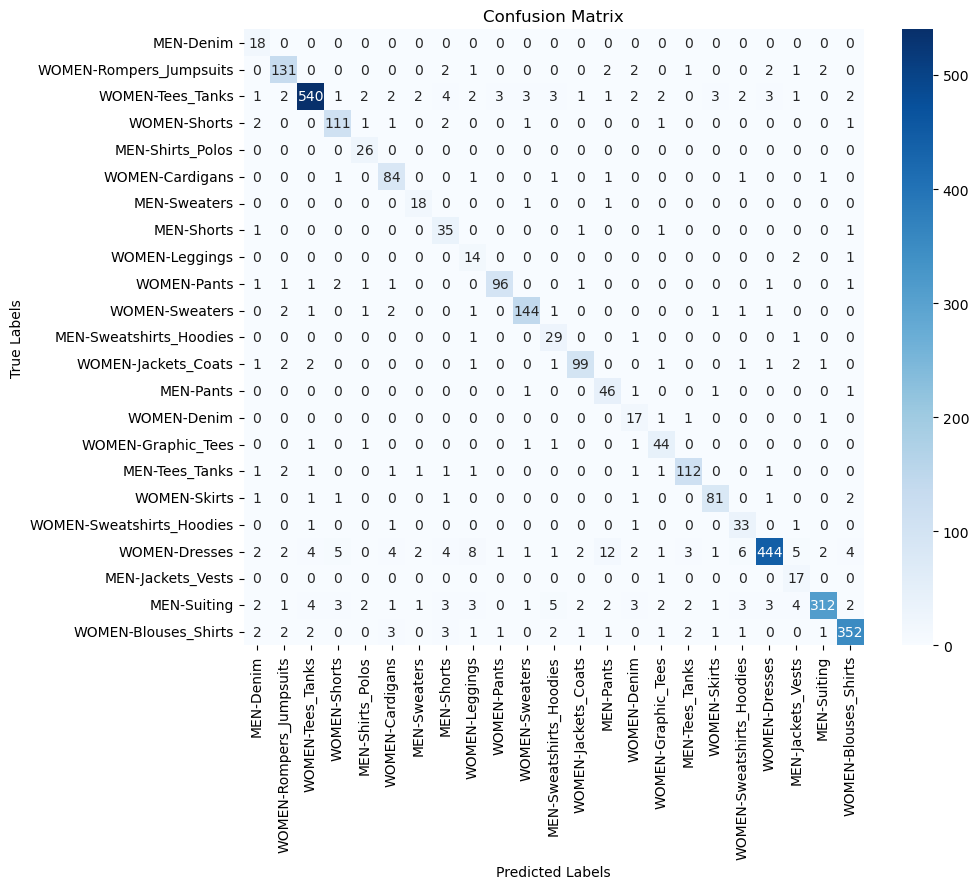

In [78]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(classifier.predict(val_features), axis=-1)
report = classification_report(np.argmax(y_val_One_hot, axis=-1), y_pred)
print("Classification Report:")
print(report)

# Compute confusion matrix
conf_matrix = confusion_matrix(np.argmax(y_val_One_hot, axis=-1), y_pred)

# Print confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

# Plot confusion matrix using a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(NUM_CLASSES), yticklabels=np.arange(NUM_CLASSES))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

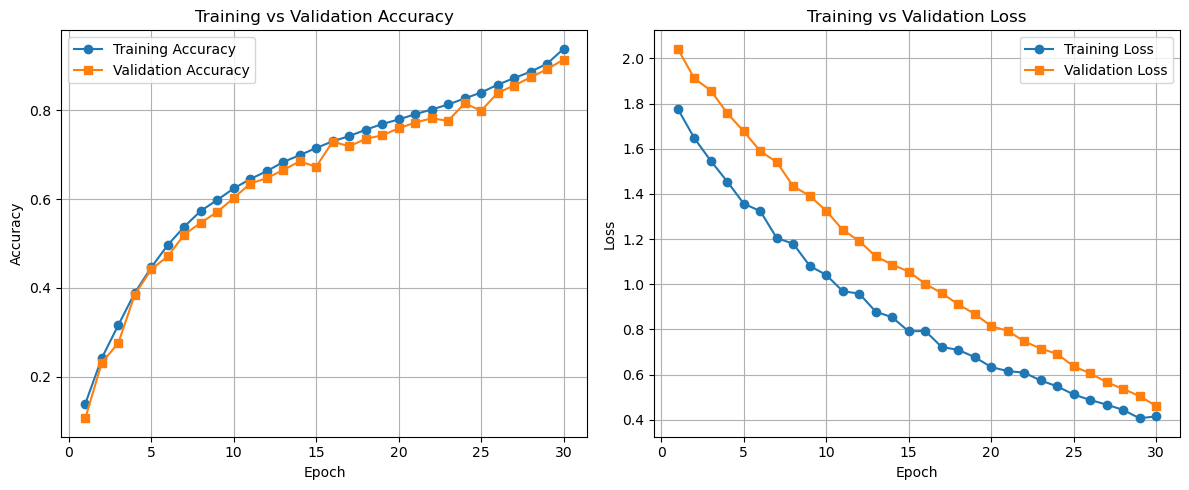

In [66]:
import matplotlib.pyplot as plt

# Extract metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Accuracy Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()